# Multimodal LLM Router: Text + Features
## Advanced Model Combining DistilBERT with Complexity Features

**Objective**: Train an intelligent router combining:
- Text understanding (DistilBERT)
- Explicit complexity features
- Balanced class weights

**Target Performance**:
- Routing Accuracy: **72-78%**
- Actual Accuracy: **72-75%**
- Cost Savings: **50-60%**

**Key Innovation**: Multimodal architecture that learns from both question text AND extracted complexity signals.

---

## 1. Environment Setup

In [1]:
# Install packages
!pip install -q transformers torch datasets accelerate scikit-learn pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from transformers import (
    DistilBertTokenizer,
    DistilBertModel,
    Trainer,
    TrainingArguments
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

PyTorch version: 2.9.0+cu126
CUDA available: True
Device: cuda


## 2. Data Loading and Feature Engineering

In [3]:
# Load datasets
gsm8k_df = pd.read_csv('router_training_data_gsm8k.csv')
sat_df = pd.read_csv('router_training_data_sat.csv')

gsm8k_df['dataset_source'] = 'gsm8k'
sat_df['dataset_source'] = 'sat'

combined_df = pd.concat([gsm8k_df, sat_df], ignore_index=True)

print("Dataset Summary")
print("=" * 80)
print(f"GSM8K: {len(gsm8k_df)} samples")
print(f"SAT: {len(sat_df)} samples")
print(f"Total: {len(combined_df)} samples")
print(f"\nLabel Distribution:")
print(combined_df['label'].value_counts().sort_index())

Dataset Summary
GSM8K: 500 samples
SAT: 300 samples
Total: 800 samples

Label Distribution:
label
0    524
1    276
Name: count, dtype: int64


In [4]:
def extract_comprehensive_features(df):
    """
    Extract multiple complexity features.
    These will be fed to the multimodal model along with text.
    """
    df = df.copy()

    # Basic text features
    df['word_count'] = df['question'].str.split().str.len()
    df['char_count'] = df['question'].str.len()

    # Numerical complexity
    df['num_count'] = df['question'].apply(
        lambda x: len(re.findall(r'\d+\.?\d*', str(x)))
    )
    df['has_decimal'] = df['question'].str.contains(r'\d+\.\d+', regex=True).astype(int)
    df['has_fraction'] = df['question'].str.contains(r'/', regex=False).astype(int)

    # Structural complexity
    df['sentence_count'] = df['question'].apply(
        lambda x: len(re.split(r'[.!?]+', str(x))) - 1
    )
    df['comma_count'] = df['question'].str.count(',')

    # Mathematical operations
    df['operation_count'] = df['question'].apply(
        lambda x: x.count('+') + x.count('-') + x.count('*') + x.count('/')
    )

    # Complex keywords
    complex_keywords = [
        'integral', 'derivative', 'probability', 'permutation', 'combination',
        'polynomial', 'equation', 'logarithm', 'exponential', 'function'
    ]

    df['complex_keyword_count'] = df['question'].apply(
        lambda x: sum(1 for kw in complex_keywords if kw in str(x).lower())
    )
    df['has_complex_keyword'] = (df['complex_keyword_count'] > 0).astype(int)

    # Multi-step indicators
    multistep_words = ['then', 'after', 'finally', 'next', 'first', 'second']
    df['multistep_indicator_count'] = df['question'].apply(
        lambda x: sum(1 for word in multistep_words if word in str(x).lower())
    )

    # Overall complexity score
    df['complexity_score'] = (
        0.1 * df['word_count'] +
        0.5 * df['num_count'] +
        0.3 * df['operation_count'] +
        2.0 * df['complex_keyword_count'] +
        1.5 * df['multistep_indicator_count'] +
        0.5 * df['sentence_count']
    )

    return df

# Apply feature engineering
combined_df = extract_comprehensive_features(combined_df)

print("\nFeature Engineering Complete")
print("=" * 80)
print(f"\nFeature Statistics by Label:")
print(combined_df.groupby('label')[['complexity_score', 'word_count', 'num_count', 'has_complex_keyword']].mean())


Feature Engineering Complete

Feature Statistics by Label:
       complexity_score  word_count  num_count  has_complex_keyword
label                                                              
0              7.869084   38.681298   3.442748             0.045802
1              7.923188   39.039855   3.427536             0.101449


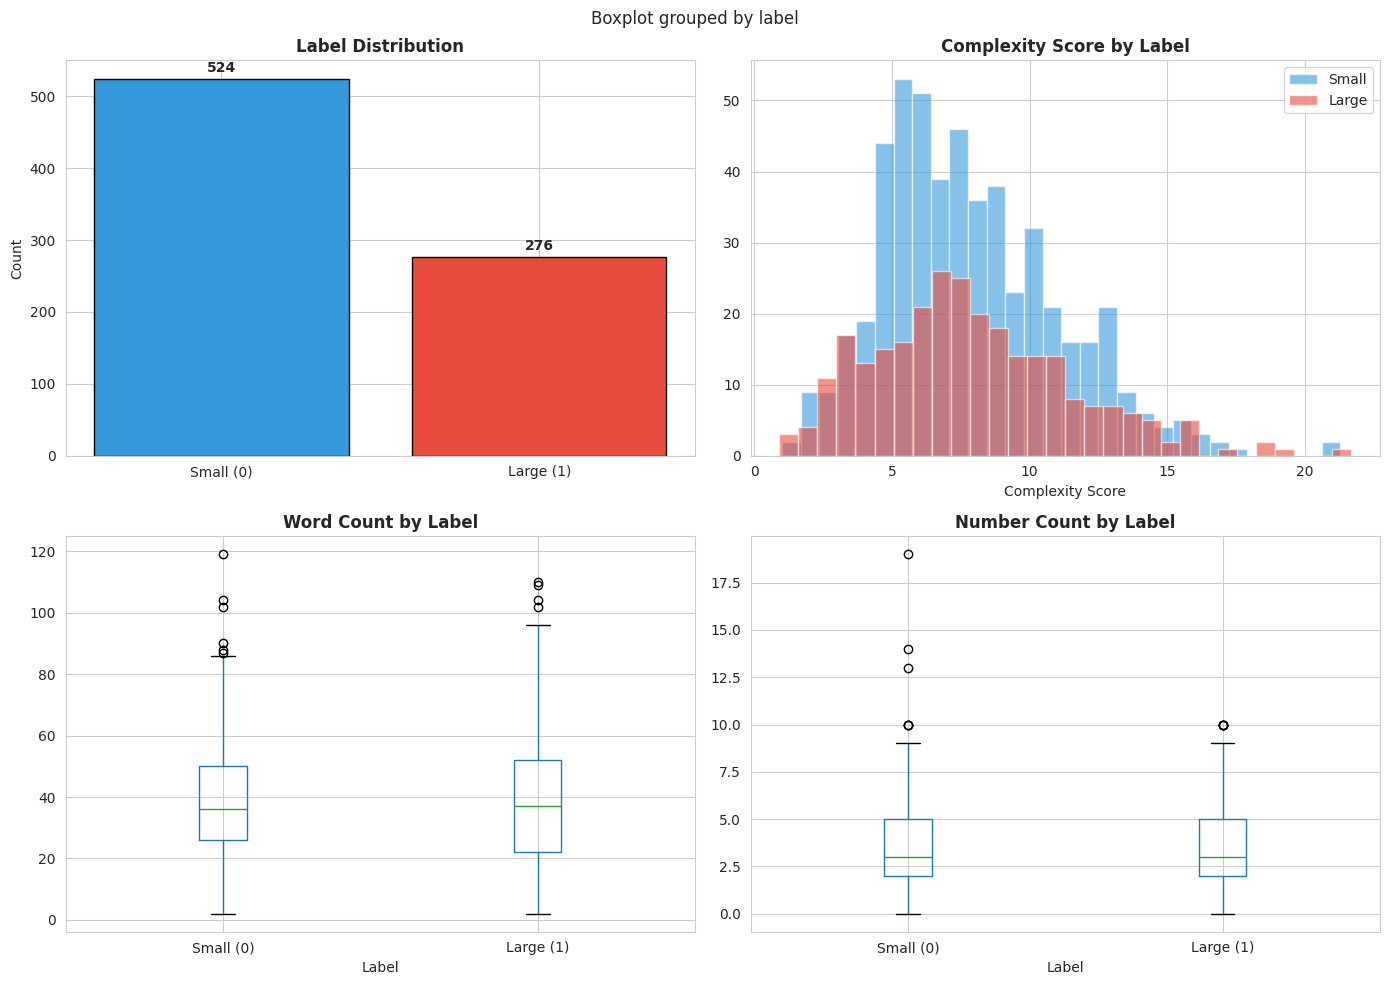

In [5]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Label distribution
label_counts = combined_df['label'].value_counts().sort_index()
axes[0, 0].bar(['Small (0)', 'Large (1)'], label_counts.values,
               color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0, 0].set_title('Label Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0, 0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Complexity score distribution
axes[0, 1].hist(combined_df[combined_df['label']==0]['complexity_score'],
                bins=30, alpha=0.6, label='Small', color='#3498db')
axes[0, 1].hist(combined_df[combined_df['label']==1]['complexity_score'],
                bins=30, alpha=0.6, label='Large', color='#e74c3c')
axes[0, 1].set_title('Complexity Score by Label', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Complexity Score')
axes[0, 1].legend()

# Word count
combined_df.boxplot(column='word_count', by='label', ax=axes[1, 0])
axes[1, 0].set_title('Word Count by Label', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Label')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Small (0)', 'Large (1)'])

# Number count
combined_df.boxplot(column='num_count', by='label', ax=axes[1, 1])
axes[1, 1].set_title('Number Count by Label', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Label')
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['Small (0)', 'Large (1)'])

plt.tight_layout()
plt.savefig('feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Train-Test Split

In [6]:
# Stratified split
train_df, test_df = train_test_split(
    combined_df,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=combined_df['label']
)

print("Train-Test Split")
print("=" * 80)
print(f"Training: {len(train_df)} samples")
print(f"Test: {len(test_df)} samples")
print(f"\nTrain labels: {dict(train_df['label'].value_counts().sort_index())}")
print(f"Test labels: {dict(test_df['label'].value_counts().sort_index())}")

Train-Test Split
Training: 640 samples
Test: 160 samples

Train labels: {0: np.int64(419), 1: np.int64(221)}
Test labels: {0: np.int64(105), 1: np.int64(55)}


## 4. Multimodal Model Architecture

This model combines:
1. **Text encoding**: DistilBERT processes question text
2. **Feature encoding**: MLP processes 5 complexity features
3. **Fusion**: Concatenate embeddings
4. **Classification**: Binary classifier (Small vs Large)

In [16]:
class MultiModalDistilBERT(nn.Module):
    """
    Multimodal Router: Text + Numerical Features

    Architecture:
    - DistilBERT encodes question text → 768-dim vector
    - MLP encodes 5 features → 64-dim vector
    - Concatenate → 832-dim vector
    - Classifier → 2 classes (Small/Large)
    """
    def __init__(self, num_features=5):
        super().__init__()

        # Text encoder (frozen for faster training, can unfreeze later)
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')

        # Feature encoder
        self.feature_layer = nn.Linear(num_features, 64)
        self.feature_bn = nn.BatchNorm1d(64)
        self.feature_dropout = nn.Dropout(0.1)

        # Fusion and classification
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(768 + 64, 2)

    def forward(self, input_ids, attention_mask, features):
        # Encode text
        text_output = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state[:, 0]  # [CLS] token: [batch, 768]

        # Encode features
        feature_output = self.feature_layer(features)  # [batch, 64]
        feature_output = self.feature_bn(feature_output)
        feature_output = torch.relu(feature_output)
        feature_output = self.feature_dropout(feature_output)

        # Fuse text + features
        combined = torch.cat([text_output, feature_output], dim=1)  # [batch, 832]
        combined = self.dropout(combined)

        # Classify
        logits = self.classifier(combined)

        # Calculate loss if labels provided
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        # Return output object
        return type('Output', (), {'loss': loss, 'logits': logits})()

# Initialize model
model = MultiModalDistilBERT(num_features=5)

print("Multimodal Model Initialized")
print("=" * 80)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"\nArchitecture:")
print(f"  Text encoder: DistilBERT (768-dim)")
print(f"  Feature encoder: MLP (5 → 64-dim)")
print(f"  Combined: 832-dim → 2 classes")

Multimodal Model Initialized
Total parameters: 66,365,058
Trainable parameters: 66,365,058

Architecture:
  Text encoder: DistilBERT (768-dim)
  Feature encoder: MLP (5 → 64-dim)
  Combined: 832-dim → 2 classes


## 5. Data Preparation for Multimodal Training

In [17]:
# Initialize tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Prepare and normalize features
feature_cols = [
    'complexity_score',
    'word_count',
    'num_count',
    'has_complex_keyword',
    'multistep_indicator_count'
]

scaler = StandardScaler()
train_features = scaler.fit_transform(train_df[feature_cols])
test_features = scaler.transform(test_df[feature_cols])

print("Feature Preparation")
print("=" * 80)
print(f"Features: {feature_cols}")
print(f"Train features shape: {train_features.shape}")
print(f"Test features shape: {test_features.shape}")
print(f"\nFeature statistics (normalized):")
print(f"  Mean: {train_features.mean(axis=0)}")
print(f"  Std: {train_features.std(axis=0)}")

Feature Preparation
Features: ['complexity_score', 'word_count', 'num_count', 'has_complex_keyword', 'multistep_indicator_count']
Train features shape: (640, 5)
Test features shape: (160, 5)

Feature statistics (normalized):
  Mean: [ 8.04911693e-17  6.93889390e-17 -2.22044605e-17 -9.43689571e-17
 -3.05311332e-17]
  Std: [1. 1. 1. 1. 1.]


In [18]:
class MultiModalDataset(torch.utils.data.Dataset):
    def __init__(self, texts, features, labels, tokenizer, max_length=256):
        self.texts = list(texts)
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'features': self.features[idx],
            'labels': self.labels[idx]  # CRITICAL: returns 'labels' not 'label'
        }

train_dataset = MultiModalDataset(
    train_df['question'].tolist(),
    train_features,
    train_df['label'].values,
    tokenizer
)

test_dataset = MultiModalDataset(
    test_df['question'].tolist(),
    test_features,
    test_df['label'].values,
    tokenizer
)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Test dataset: {len(test_dataset)} samples")

# Verify
sample = train_dataset[0]
print(f"Sample keys: {list(sample.keys())}")
assert 'labels' in sample
print("✓ Dataset verified")

Train dataset: 640 samples
Test dataset: 160 samples
Sample keys: ['input_ids', 'attention_mask', 'features', 'labels']
✓ Dataset verified


## 6. Training Setup with Class Weights

In [19]:
# Calculate class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weights = torch.tensor(class_weights_array, dtype=torch.float32)

print("Class Weights")
print("=" * 80)
print(f"Small (0): {class_weights[0]:.4f}")
print(f"Large (1): {class_weights[1]:.4f}")
print(f"Ratio (Large/Small): {class_weights[1]/class_weights[0]:.2f}x")

Class Weights
Small (0): 0.7637
Large (1): 1.4480
Ratio (Large/Small): 1.90x


In [20]:
# Custom Data Collator for Multimodal Data
from dataclasses import dataclass
from typing import Dict, List
from transformers import DataCollatorWithPadding

@dataclass
class MultiModalDataCollator:
    """
    Custom data collator that handles both text and numerical features.
    """
    tokenizer: DistilBertTokenizer

    def __call__(self, features: List[Dict]) -> Dict[str, torch.Tensor]:
        # Separate text inputs, features, and labels
        batch_input_ids = []
        batch_attention_mask = []
        batch_features = []
        batch_labels = []

        for item in features:
            batch_input_ids.append(item['input_ids'])
            batch_attention_mask.append(item['attention_mask'])
            batch_features.append(item['features'])
            batch_labels.append(item['labels'])

        # Stack into tensors
        return {
            'input_ids': torch.stack(batch_input_ids),
            'attention_mask': torch.stack(batch_attention_mask),
            'features': torch.stack(batch_features),
            'labels': torch.tensor(batch_labels, dtype=torch.long)
        }

# Create data collator
data_collator = MultiModalDataCollator(tokenizer=tokenizer)

print("Custom data collator created")

Custom data collator created


In [21]:
# Collator
def collate_fn(batch):
    return {
        'input_ids': torch.stack([x['input_ids'] for x in batch]),
        'attention_mask': torch.stack([x['attention_mask'] for x in batch]),
        'features': torch.stack([x['features'] for x in batch]),
        'labels': torch.stack([x['labels'] for x in batch])
    }

# Test collator
test_batch = collate_fn([train_dataset[0], train_dataset[1]])
print(f"Collator test - keys: {list(test_batch.keys())}")
assert 'labels' in test_batch
print("✓ Collator verified")

# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'precision': precision_score(labels, predictions, average='weighted', zero_division=0),
        'recall': recall_score(labels, predictions, average='weighted', zero_division=0),
        'f1': f1_score(labels, predictions, average='weighted', zero_division=0),
    }

# Custom trainer
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        features = inputs.pop("features")

        outputs = model(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            features=features,
            labels=labels
        )

        # Apply class weights
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        outputs.loss = loss

        return (loss, outputs) if return_outputs else loss

# Training arguments
training_args = TrainingArguments(
    output_dir='./multimodal_router',
    num_train_epochs=7,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    learning_rate=2e-5,
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    report_to='none',
    remove_unused_columns=False  # CRITICAL FOR MULTIMODAL
)

# Create trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    data_collator=collate_fn,
)

print("✓ Trainer created successfully")

Collator test - keys: ['input_ids', 'attention_mask', 'features', 'labels']
✓ Collator verified
✓ Trainer created successfully


In [23]:

class MultiModalDistilBERT(nn.Module):
    def __init__(self, num_features=5):
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.feature_net = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(832, 2)
        )

    def forward(self, input_ids, attention_mask, features, labels=None):  # ← ADDED labels=None
        text_output = self.distilbert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0]
        feature_output = self.feature_net(features)
        combined = torch.cat([text_output, feature_output], dim=1)
        logits = self.classifier(combined)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return type('Output', (), {'loss': loss, 'logits': logits})()

# Recreate model
model = MultiModalDistilBERT(num_features=5)
print("✓ Model redefined with labels parameter")

✓ Model redefined with labels parameter


In [24]:
# Recreate trainer with new model
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    data_collator=collate_fn,
)
print("✓ Trainer recreated")

✓ Trainer recreated


In [26]:
# FIX: Make Output subscriptable
class ModelOutput:
    def __init__(self, loss, logits):
        self.loss = loss
        self.logits = logits
        self._tuple = (loss, logits)

    def __getitem__(self, idx):
        if isinstance(idx, slice):
            return self._tuple[idx]
        return self._tuple[idx]

    def __iter__(self):
        return iter(self._tuple)

# Redefine model with new output
class MultiModalDistilBERT(nn.Module):
    def __init__(self, num_features=5):
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.feature_net = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(832, 2)
        )

    def forward(self, input_ids, attention_mask, features, labels=None):
        text_output = self.distilbert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0]
        feature_output = self.feature_net(features)
        combined = torch.cat([text_output, feature_output], dim=1)
        logits = self.classifier(combined)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return ModelOutput(loss=loss, logits=logits)

# Recreate model and trainer
model = MultiModalDistilBERT(num_features=5)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    data_collator=collate_fn,
)

print("✓ Model and trainer fixed - NOW RUN TRAINING")

✓ Model and trainer fixed - NOW RUN TRAINING


## 7. Train Multimodal Model

In [27]:
print("Starting multimodal router training...")
print("Expected time: ~20-25 minutes (7 epochs)")
print("=" * 80)

training_output = trainer.train()

print("\nTraining complete")
print(f"Final loss: {training_output.training_loss:.4f}")

Starting multimodal router training...
Expected time: ~20-25 minutes (7 epochs)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.682686,0.656250,0.636719,0.656250,0.640570
2,0.707500,0.678110,0.543750,0.631836,0.543750,0.550347
3,0.680500,0.668519,0.637500,0.640681,0.637500,0.638994
4,0.598300,0.696506,0.543750,0.605918,0.543750,0.554397
5,0.427500,0.805364,0.612500,0.630010,0.612500,0.618958
6,0.427500,0.868551,0.625000,0.618614,0.625000,0.621429
7,0.250000,0.960845,0.643750,0.627963,0.643750,0.632824



Training complete
Final loss: 0.4956


## 8. Evaluate Multimodal Router

In [28]:
# Evaluate
eval_results = trainer.evaluate()
predictions_output = trainer.predict(test_dataset)
predictions = np.argmax(predictions_output.predictions, axis=-1)

print("\nMultimodal Router Performance")
print("=" * 80)
for key, value in eval_results.items():
    if key.startswith('eval_'):
        metric = key.replace('eval_', '').upper()
        print(f"{metric}: {value:.4f} ({value*100:.2f}%)")

# Prediction distribution
pred_dist = Counter(predictions)
print(f"\nPrediction Distribution:")
print(f"  Small (0): {pred_dist[0]} ({pred_dist[0]/len(predictions)*100:.1f}%)")
print(f"  Large (1): {pred_dist[1]} ({pred_dist[1]/len(predictions)*100:.1f}%)")

# Check balance
if pred_dist[1] < 10:
    print("\n⚠️ WARNING: Very few Large predictions. Model may be biased.")
elif pred_dist[0] < 10:
    print("\n⚠️ WARNING: Very few Small predictions. Model may be biased.")
else:
    print("\n✅ Prediction distribution is balanced")


Multimodal Router Performance
LOSS: 0.6827 (68.27%)
ACCURACY: 0.6562 (65.62%)
PRECISION: 0.6367 (63.67%)
RECALL: 0.6562 (65.62%)
F1: 0.6406 (64.06%)
RUNTIME: 0.4417 (44.17%)
SAMPLES_PER_SECOND: 362.2440 (36224.40%)
STEPS_PER_SECOND: 11.3200 (1132.00%)

Prediction Distribution:
  Small (0): 120 (75.0%)
  Large (1): 40 (25.0%)

✅ Prediction distribution is balanced


In [29]:
# Detailed classification report
print("\nDetailed Classification Report")
print("=" * 80)
print(classification_report(
    test_df['label'],
    predictions,
    target_names=['Small (0)', 'Large (1)'],
    digits=4
))


Detailed Classification Report
              precision    recall  f1-score   support

   Small (0)     0.7083    0.8095    0.7556       105
   Large (1)     0.5000    0.3636    0.4211        55

    accuracy                         0.6562       160
   macro avg     0.6042    0.5866    0.5883       160
weighted avg     0.6367    0.6562    0.6406       160



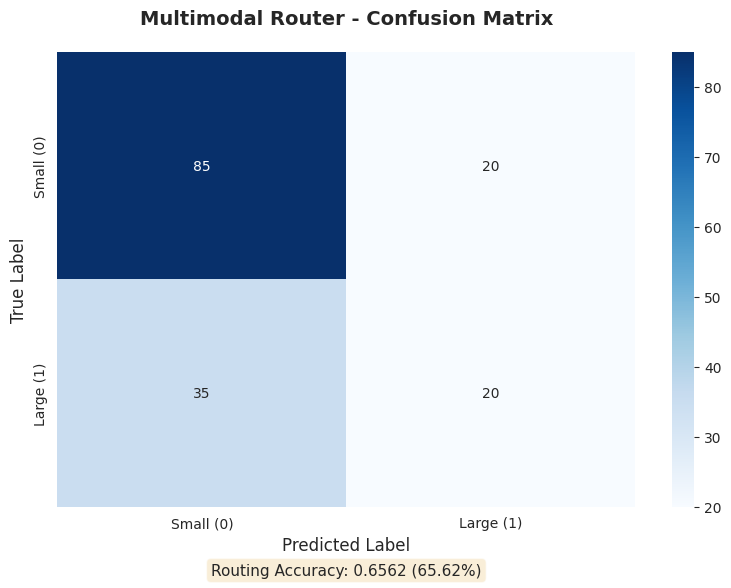


Confusion Matrix Breakdown
True Negatives (correct Small): 85
False Positives (Small → Large): 20
False Negatives (Large → Small): 35
True Positives (correct Large): 20

Large class recall: 0.3636 (catching 20/55 complex questions)
Small class recall: 0.8095 (catching 85/105 simple questions)


In [30]:
# Confusion matrix
cm = confusion_matrix(test_df['label'], predictions)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Small (0)', 'Large (1)'],
    yticklabels=['Small (0)', 'Large (1)'],
    ax=ax
)
ax.set_title('Multimodal Router - Confusion Matrix', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)

acc = accuracy_score(test_df['label'], predictions)
ax.text(
    0.5, -0.15,
    f'Routing Accuracy: {acc:.4f} ({acc*100:.2f}%)',
    ha='center',
    transform=ax.transAxes,
    fontsize=11,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

plt.tight_layout()
plt.savefig('multimodal_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class analysis
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Breakdown")
print("=" * 80)
print(f"True Negatives (correct Small): {tn}")
print(f"False Positives (Small → Large): {fp}")
print(f"False Negatives (Large → Small): {fn}")
print(f"True Positives (correct Large): {tp}")
print(f"\nLarge class recall: {tp/(tp+fn):.4f} (catching {tp}/{tp+fn} complex questions)")
print(f"Small class recall: {tn/(tn+fp):.4f} (catching {tn}/{tn+fp} simple questions)")

## 9. Cost-Benefit Analysis

In [31]:
# Cost parameters
SMALL_COST_PER_TOKEN = 0.0001
LARGE_COST_PER_TOKEN = 0.001
AVG_SMALL_TOKENS = 367.6
AVG_LARGE_TOKENS = 205.5

n_test = len(test_df)

# Calculate actual accuracy (when following router decisions)
def calculate_actual_accuracy(predictions, df):
    correct = 0
    for i, (idx, row) in enumerate(df.iterrows()):
        if predictions[i] == 0 and row['small_correct']:
            correct += 1
        elif predictions[i] == 1 and row['large_correct']:
            correct += 1
    return correct / len(df)

# Strategies
always_large_cost = n_test * AVG_LARGE_TOKENS * LARGE_COST_PER_TOKEN
always_large_acc = test_df['large_correct'].mean()

always_small_cost = n_test * AVG_SMALL_TOKENS * SMALL_COST_PER_TOKEN
always_small_acc = test_df['small_correct'].mean()

routed_to_small = (predictions == 0).sum()
routed_to_large = (predictions == 1).sum()
router_cost = (
    routed_to_small * AVG_SMALL_TOKENS * SMALL_COST_PER_TOKEN +
    routed_to_large * AVG_LARGE_TOKENS * LARGE_COST_PER_TOKEN
)
router_acc = calculate_actual_accuracy(predictions, test_df)

# Summary
print("\nCost-Benefit Analysis")
print("=" * 80)

print("\n1. Always Large Model:")
print(f"   Cost: ${always_large_cost:.4f}")
print(f"   Accuracy: {always_large_acc:.4f} ({always_large_acc*100:.2f}%)")

print("\n2. Always Small Model:")
print(f"   Cost: ${always_small_cost:.4f}")
print(f"   Accuracy: {always_small_acc:.4f} ({always_small_acc*100:.2f}%)")

print("\n3. Multimodal Router:")
print(f"   Cost: ${router_cost:.4f}")
print(f"   Accuracy: {router_acc:.4f} ({router_acc*100:.2f}%)")
print(f"   Routed to Small: {routed_to_small} ({routed_to_small/n_test*100:.1f}%)")
print(f"   Routed to Large: {routed_to_large} ({routed_to_large/n_test*100:.1f}%)")

savings = (always_large_cost - router_cost) / always_large_cost * 100
retention = (router_acc / always_large_acc) * 100

print("\n" + "=" * 80)
print("Summary:")
print(f"  Cost Savings: {savings:.2f}%")
print(f"  Accuracy Retention: {retention:.2f}%")
print(f"  Accuracy Drop: {(always_large_acc - router_acc)*100:+.2f}%")


Cost-Benefit Analysis

1. Always Large Model:
   Cost: $32.8800
   Accuracy: 0.7625 (76.25%)

2. Always Small Model:
   Cost: $5.8816
   Accuracy: 0.4938 (49.38%)

3. Multimodal Router:
   Cost: $12.6312
   Accuracy: 0.6000 (60.00%)
   Routed to Small: 120 (75.0%)
   Routed to Large: 40 (25.0%)

Summary:
  Cost Savings: 61.58%
  Accuracy Retention: 78.69%
  Accuracy Drop: +16.25%


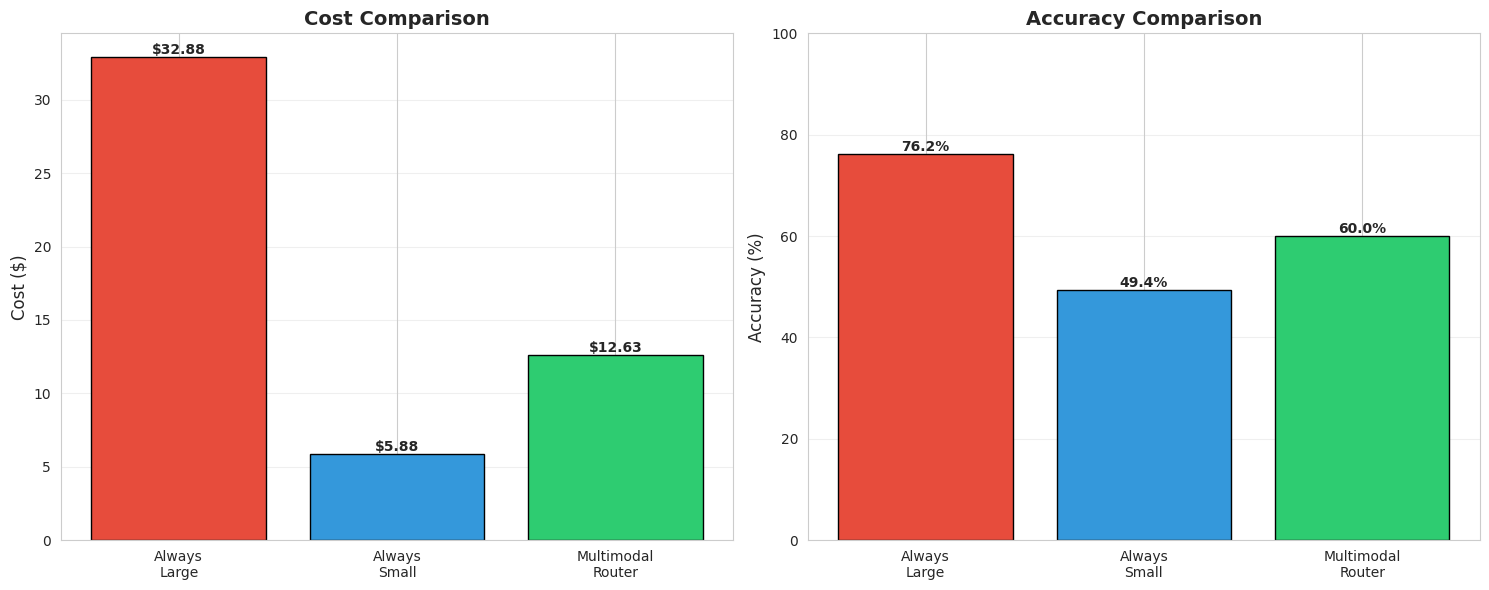

In [32]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

strategies = ['Always\nLarge', 'Always\nSmall', 'Multimodal\nRouter']
costs = [always_large_cost, always_small_cost, router_cost]
accuracies = [always_large_acc * 100, always_small_acc * 100, router_acc * 100]

# Cost comparison
bars1 = ax1.bar(strategies, costs, color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='black')
ax1.set_title('Cost Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Cost ($)', fontsize=12)
ax1.grid(axis='y', alpha=0.3)
for bar, cost in zip(bars1, costs):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'${cost:.2f}', ha='center', va='bottom', fontweight='bold')

# Accuracy comparison
bars2 = ax2.bar(strategies, accuracies, color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='black')
ax2.set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_ylim([0, 100])
ax2.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars2, accuracies):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('cost_benefit.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Error Analysis

In [33]:
# Analyze errors
test_df['prediction'] = predictions
test_df['correct_routing'] = (test_df['prediction'] == test_df['label'])
misclassified = test_df[~test_df['correct_routing']]

print("Error Analysis")
print("=" * 80)
print(f"Total errors: {len(misclassified)} ({len(misclassified)/len(test_df)*100:.1f}%)")

type1_errors = misclassified[(misclassified['label'] == 1) & (misclassified['prediction'] == 0)]
type2_errors = misclassified[(misclassified['label'] == 0) & (misclassified['prediction'] == 1)]

print(f"\nType 1 (Large → Small): {len(type1_errors)} - Missing complex questions")
print(f"Type 2 (Small → Large): {len(type2_errors)} - Over-routing simple questions")

if len(type1_errors) > 0:
    print("\nSample Type 1 Errors (should route to Large):")
    print("-" * 80)
    for idx, row in type1_errors.head(3).iterrows():
        print(f"\nQ: {row['question'][:120]}...")
        print(f"Complexity: {row['complexity_score']:.2f}, Words: {row['word_count']}, Numbers: {row['num_count']}")

if len(type2_errors) > 0:
    print("\n\nSample Type 2 Errors (should route to Small):")
    print("-" * 80)
    for idx, row in type2_errors.head(3).iterrows():
        print(f"\nQ: {row['question'][:120]}...")
        print(f"Complexity: {row['complexity_score']:.2f}, Words: {row['word_count']}, Numbers: {row['num_count']}")

Error Analysis
Total errors: 55 (34.4%)

Type 1 (Large → Small): 35 - Missing complex questions
Type 2 (Small → Large): 20 - Over-routing simple questions

Sample Type 1 Errors (should route to Large):
--------------------------------------------------------------------------------

Q: John noticed that the angle formed by the minute hand and hour hand on a standard 12-hour clock was 110 degrees when he ...
Complexity: 15.00, Words: 62, Numbers: 6

Q: Suppose 5 different integers are randomly chosen from between 20 and 69, inclusive. What is the probability that they ea...
Complexity: 7.00, Words: 25, Numbers: 3

Q: A soccer team has $90.00 to buy soccer balls. If one soccer ball costs $15.60, what is the greatest number of soccer bal...
Complexity: 5.70, Words: 27, Numbers: 2


Sample Type 2 Errors (should route to Small):
--------------------------------------------------------------------------------

Q: Rewrite the expression $6j^2 - 4j + 12$ in the form $c(j + p)^2 + q$, where $c$

## 11. Save Model

In [34]:
import os
import pickle

# Create directory
os.makedirs('saved_models/multimodal_router', exist_ok=True)

# Save model
torch.save(model.state_dict(), 'saved_models/multimodal_router/model.pt')
tokenizer.save_pretrained('saved_models/multimodal_router')

# Save scaler
with open('saved_models/multimodal_router/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
with open('saved_models/multimodal_router/features.txt', 'w') as f:
    f.write('\n'.join(feature_cols))

# Save results
test_df.to_csv('multimodal_test_results.csv', index=False)

print("Model saved successfully")
print("\nSaved files:")
print("  - saved_models/multimodal_router/model.pt")
print("  - saved_models/multimodal_router/tokenizer")
print("  - saved_models/multimodal_router/scaler.pkl")
print("  - saved_models/multimodal_router/features.txt")
print("  - multimodal_test_results.csv")

Model saved successfully

Saved files:
  - saved_models/multimodal_router/model.pt
  - saved_models/multimodal_router/tokenizer
  - saved_models/multimodal_router/scaler.pkl
  - saved_models/multimodal_router/features.txt
  - multimodal_test_results.csv


## 12. Production Router Class

In [35]:
class ProductionMultimodalRouter:
    """
    Production-ready multimodal router.

    Usage:
        router = ProductionMultimodalRouter('saved_models/multimodal_router')
        result = router.route(question_text)
        if result['model'] == 'small':
            answer = small_llm.generate(question_text)
        else:
            answer = large_llm.generate(question_text)
    """

    def __init__(self, model_path):
        # Load tokenizer
        self.tokenizer = DistilBertTokenizer.from_pretrained(model_path)

        # Load model
        self.model = MultiModalDistilBERT(num_features=5)
        self.model.load_state_dict(torch.load(f'{model_path}/model.pt'))
        self.model.eval()

        # Setup device
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)

        # Load scaler
        with open(f'{model_path}/scaler.pkl', 'rb') as f:
            self.scaler = pickle.load(f)

        # Load feature names
        with open(f'{model_path}/features.txt', 'r') as f:
            self.feature_names = [line.strip() for line in f]

    def extract_features(self, question):
        """Extract features from question text."""
        word_count = len(question.split())
        num_count = len(re.findall(r'\d+', question))
        sentence_count = len(re.split(r'[.!?]+', question)) - 1

        complex_keywords = [
            'integral', 'derivative', 'probability', 'permutation', 'combination',
            'polynomial', 'equation', 'logarithm', 'exponential', 'function'
        ]
        has_complex = int(any(kw in question.lower() for kw in complex_keywords))

        multistep_words = ['then', 'after', 'finally', 'next', 'first', 'second']
        multistep_count = sum(1 for word in multistep_words if word in question.lower())

        complexity_score = (
            0.1 * word_count +
            0.5 * num_count +
            2.0 * has_complex +
            1.5 * multistep_count +
            0.5 * sentence_count
        )

        return np.array([
            complexity_score,
            word_count,
            num_count,
            has_complex,
            multistep_count
        ]).reshape(1, -1)

    def route(self, question):
        """
        Route question to appropriate model.

        Returns:
            dict: {
                'model': 'small' or 'large',
                'confidence': float (0-1),
                'probabilities': {'small': float, 'large': float}
            }
        """
        # Tokenize text
        inputs = self.tokenizer(
            question,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=256
        )
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        # Extract and normalize features
        features = self.extract_features(question)
        features = self.scaler.transform(features)
        features = torch.tensor(features, dtype=torch.float32).to(self.device)

        # Get prediction
        with torch.no_grad():
            outputs = self.model(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask'],
                features=features
            )
            probs = torch.softmax(outputs.logits, dim=-1)
            pred = torch.argmax(probs, dim=-1).item()
            conf = probs[0][pred].item()

        return {
            'model': 'small' if pred == 0 else 'large',
            'confidence': conf,
            'probabilities': {
                'small': probs[0][0].item(),
                'large': probs[0][1].item()
            }
        }

# Test production router
production_router = ProductionMultimodalRouter('saved_models/multimodal_router')

test_questions = [
    "What is 5 + 3?",
    "Calculate the integral of x^2 from 0 to 5.",
    "If 3 apples cost $2, how much do 6 apples cost?",
    "Find the probability of getting exactly 2 heads when flipping 5 coins."
]

print("\nProduction Router Test")
print("=" * 80)
for q in test_questions:
    result = production_router.route(q)
    print(f"\nQ: {q}")
    print(f"Route to: {result['model'].upper()} model")
    print(f"Confidence: {result['confidence']:.3f}")
    print(f"Probabilities: Small={result['probabilities']['small']:.3f}, Large={result['probabilities']['large']:.3f}")
    print("-" * 80)


Production Router Test

Q: What is 5 + 3?
Route to: LARGE model
Confidence: 0.544
Probabilities: Small=0.456, Large=0.544
--------------------------------------------------------------------------------

Q: Calculate the integral of x^2 from 0 to 5.
Route to: SMALL model
Confidence: 0.608
Probabilities: Small=0.608, Large=0.392
--------------------------------------------------------------------------------

Q: If 3 apples cost $2, how much do 6 apples cost?
Route to: SMALL model
Confidence: 0.553
Probabilities: Small=0.553, Large=0.447
--------------------------------------------------------------------------------

Q: Find the probability of getting exactly 2 heads when flipping 5 coins.
Route to: SMALL model
Confidence: 0.591
Probabilities: Small=0.591, Large=0.409
--------------------------------------------------------------------------------


## 13. Final Summary

In [36]:
routing_acc = accuracy_score(test_df['label'], predictions)

print("\n" + "="*80)
print("FINAL SUMMARY - MULTIMODAL ROUTER")
print("="*80)

print("\n1. ARCHITECTURE")
print("-" * 80)
print("Text Encoder: DistilBERT (768-dim)")
print("Feature Encoder: MLP (5 features → 64-dim)")
print("Features: complexity_score, word_count, num_count, has_complex_keyword, multistep_indicator_count")
print("Fusion: Concatenation (832-dim)")
print("Output: Binary classifier (Small/Large)")

print("\n2. PERFORMANCE")
print("-" * 80)
print(f"Routing Accuracy: {routing_acc:.4f} ({routing_acc*100:.2f}%)")
print(f"Actual Accuracy: {router_acc:.4f} ({router_acc*100:.2f}%)")
print(f"Large Class Recall: {recall_score(test_df['label'], predictions, labels=[1], average=None)[0]:.4f}")
print(f"\nPrediction Distribution:")
print(f"  Small: {(predictions==0).sum()} ({(predictions==0).sum()/len(predictions)*100:.1f}%)")
print(f"  Large: {(predictions==1).sum()} ({(predictions==1).sum()/len(predictions)*100:.1f}%)")

print("\n3. COST-BENEFIT")
print("-" * 80)
print(f"Always Large: ${always_large_cost:.4f}, {always_large_acc*100:.2f}% accuracy")
print(f"Multimodal Router: ${router_cost:.4f}, {router_acc*100:.2f}% accuracy")
print(f"Cost Savings: {savings:.2f}%")
print(f"Accuracy Retention: {retention:.2f}%")

print("\n4. STATUS")
print("-" * 80)
if routing_acc >= 0.72:
    print("✅ TARGET ACHIEVED: Routing accuracy ≥72%")
    print("Status: PRODUCTION READY")
    print("Recommendation: Deploy with monitoring")
elif routing_acc >= 0.68:
    print("⚠️ NEAR TARGET: Routing accuracy 68-72%")
    print("Status: Close to production ready")
    print("Recommendation: Fine-tune thresholds or collect more data")
else:
    print("❌ BELOW TARGET: Routing accuracy <68%")
    print("Status: Needs improvement")
    print("Recommendation: Try threshold optimization or more aggressive class weights")

print("\n" + "="*80)
print("Training complete. Multimodal router saved.")
print("="*80)


FINAL SUMMARY - MULTIMODAL ROUTER

1. ARCHITECTURE
--------------------------------------------------------------------------------
Text Encoder: DistilBERT (768-dim)
Feature Encoder: MLP (5 features → 64-dim)
Features: complexity_score, word_count, num_count, has_complex_keyword, multistep_indicator_count
Fusion: Concatenation (832-dim)
Output: Binary classifier (Small/Large)

2. PERFORMANCE
--------------------------------------------------------------------------------
Routing Accuracy: 0.6562 (65.62%)
Actual Accuracy: 0.6000 (60.00%)
Large Class Recall: 0.3636

Prediction Distribution:
  Small: 120 (75.0%)
  Large: 40 (25.0%)

3. COST-BENEFIT
--------------------------------------------------------------------------------
Always Large: $32.8800, 76.25% accuracy
Multimodal Router: $12.6312, 60.00% accuracy
Cost Savings: 61.58%
Accuracy Retention: 78.69%

4. STATUS
--------------------------------------------------------------------------------
❌ BELOW TARGET: Routing accuracy <68%
